In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.pipeline import Pipeline

In [73]:
df = pd.read_csv("weatherHistory.csv")

In [74]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [76]:
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"])

In [77]:
df["year"] = df["Formatted Date"].dt.year
df["month"] = df["Formatted Date"].dt.month
df["day"] = df["Formatted Date"].dt.day
df["hour"] = df["Formatted Date"].dt.hour
#df["hour"] = df["Formatted Date"].dt.minute

AttributeError: Can only use .dt accessor with datetimelike values

In [78]:
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00+02:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00+02:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00+02:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00+02:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00+02:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00+02:00,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00+02:00,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00+02:00,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00+02:00,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [79]:
df["Formatted Date"].dtype

dtype('O')

In [80]:
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"])

ValueError: Tz-aware datetime.datetime cannot be converted to datetime64 unless utc=True

In [81]:
df["Formatted Date"] = pd.to_datetime(
    df["Formatted Date"],
    utc=True
)


In [82]:
df["Formatted Date"].dtype

datetime64[ns, UTC]

In [83]:
df["year"] = df["Formatted Date"].dt.year
df["month"] = df["Formatted Date"].dt.month
df["day"] = df["Formatted Date"].dt.day
df["hour"] = df["Formatted Date"].dt.hour

In [84]:
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,year,month,day,hour
0,2006-03-31 22:00:00+00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006,3,31,22
1,2006-03-31 23:00:00+00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006,3,31,23
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006,4,1,0
3,2006-04-01 01:00:00+00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006,4,1,1
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006,4,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 17:00:00+00:00,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.,2016,9,9,17
96449,2016-09-09 18:00:00+00:00,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.,2016,9,9,18
96450,2016-09-09 19:00:00+00:00,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.,2016,9,9,19
96451,2016-09-09 20:00:00+00:00,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.,2016,9,9,20


In [85]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
year                          0
month                         0
day                           0
hour                          0
dtype: int64

In [86]:
df[df.isnull().any(axis=1)]

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,year,month,day,hour
52672,2012-04-11 14:00:00+00:00,Mostly Cloudy,NaN,19.016667,19.016667,0.26,14.8764,163.0,9.982,0.0,1002.40,Mostly cloudy until night.,2012,4,11,14
52674,2012-04-11 16:00:00+00:00,Mostly Cloudy,NaN,17.850000,17.850000,0.28,13.7977,169.0,9.982,0.0,1001.79,Mostly cloudy until night.,2012,4,11,16
52675,2012-04-11 17:00:00+00:00,Mostly Cloudy,NaN,16.322222,16.322222,0.32,10.8192,151.0,9.982,0.0,1001.60,Mostly cloudy until night.,2012,4,11,17
52677,2012-04-11 19:00:00+00:00,Mostly Cloudy,NaN,12.566667,12.566667,0.43,9.0160,159.0,9.982,0.0,1001.92,Mostly cloudy until night.,2012,4,11,19
52678,2012-04-11 20:00:00+00:00,Mostly Cloudy,NaN,12.927778,12.927778,0.47,17.6295,197.0,16.100,0.0,1002.20,Mostly cloudy until night.,2012,4,11,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95584,2016-10-31 18:00:00+00:00,Mostly Cloudy,NaN,8.322222,7.044444,0.85,8.0339,290.0,0.000,0.0,1021.73,Mostly cloudy starting in the afternoon.,2016,10,31,18
95585,2016-10-31 19:00:00+00:00,Mostly Cloudy,NaN,7.627778,6.183333,0.87,8.2271,293.0,0.000,0.0,1021.76,Mostly cloudy starting in the afternoon.,2016,10,31,19
95586,2016-10-31 20:00:00+00:00,Mostly Cloudy,NaN,7.111111,5.511111,0.89,8.5008,297.0,0.000,0.0,1021.81,Mostly cloudy starting in the afternoon.,2016,10,31,20
95587,2016-10-31 21:00:00+00:00,Partly Cloudy,NaN,6.672222,4.961111,0.90,8.6457,299.0,0.000,0.0,1021.83,Mostly cloudy starting in the afternoon.,2016,10,31,21


In [87]:
df["Precip Type"].unique()

array(['rain', 'snow', nan], dtype=object)

In [88]:
df = df.dropna().reset_index(drop=True)

In [89]:
df.isnull().sum()

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
year                        0
month                       0
day                         0
hour                        0
dtype: int64

In [90]:
df.drop("Formatted Date", axis=1, inplace=True)

In [91]:
df["Summary"].value_counts()

Partly Cloudy                          31635
Mostly Cloudy                          27914
Overcast                               16516
Clear                                  10763
Foggy                                   7117
Breezy and Overcast                      528
Breezy and Mostly Cloudy                 516
Breezy and Partly Cloudy                 386
Dry and Partly Cloudy                     86
Windy and Partly Cloudy                   67
Light Rain                                63
Breezy                                    54
Windy and Overcast                        45
Humid and Mostly Cloudy                   40
Drizzle                                   39
Breezy and Foggy                          35
Windy and Mostly Cloudy                   35
Dry                                       34
Humid and Partly Cloudy                   17
Dry and Mostly Cloudy                     14
Rain                                      10
Windy                                      8
Humid and 

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95936 entries, 0 to 95935
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Summary                   95936 non-null  object 
 1   Precip Type               95936 non-null  object 
 2   Temperature (C)           95936 non-null  float64
 3   Apparent Temperature (C)  95936 non-null  float64
 4   Humidity                  95936 non-null  float64
 5   Wind Speed (km/h)         95936 non-null  float64
 6   Wind Bearing (degrees)    95936 non-null  float64
 7   Visibility (km)           95936 non-null  float64
 8   Loud Cover                95936 non-null  float64
 9   Pressure (millibars)      95936 non-null  float64
 10  Daily Summary             95936 non-null  object 
 11  year                      95936 non-null  int64  
 12  month                     95936 non-null  int64  
 13  day                       95936 non-null  int64  
 14  hour  

In [93]:
df["Precip Type"].unique()

array(['rain', 'snow'], dtype=object)

In [94]:
df["Precip Type"]

0        rain
1        rain
2        rain
3        rain
4        rain
         ... 
95931    rain
95932    rain
95933    rain
95934    rain
95935    rain
Name: Precip Type, Length: 95936, dtype: object

<AxesSubplot:>

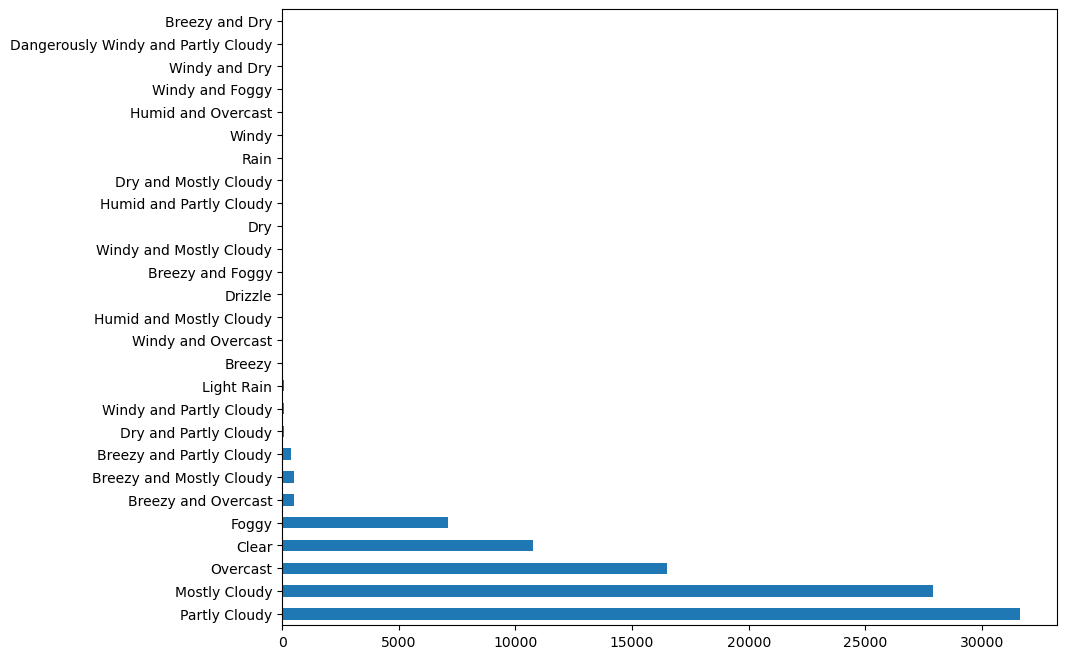

In [95]:
df["Summary"].value_counts().plot(
    kind="barh",
    figsize=(10,8)
)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95936 entries, 0 to 95935
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Summary                   95936 non-null  object 
 1   Precip Type               95936 non-null  object 
 2   Temperature (C)           95936 non-null  float64
 3   Apparent Temperature (C)  95936 non-null  float64
 4   Humidity                  95936 non-null  float64
 5   Wind Speed (km/h)         95936 non-null  float64
 6   Wind Bearing (degrees)    95936 non-null  float64
 7   Visibility (km)           95936 non-null  float64
 8   Loud Cover                95936 non-null  float64
 9   Pressure (millibars)      95936 non-null  float64
 10  Daily Summary             95936 non-null  object 
 11  year                      95936 non-null  int64  
 12  month                     95936 non-null  int64  
 13  day                       95936 non-null  int64  
 14  hour  

In [97]:
df["season"] = df["month"].map({
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn"
})

In [98]:
df

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,year,month,day,hour,season
0,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006,3,31,22,Spring
1,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006,3,31,23,Spring
2,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006,4,1,0,Spring
3,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006,4,1,1,Spring
4,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006,4,1,2,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95931,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.,2016,9,9,17,Autumn
95932,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.,2016,9,9,18,Autumn
95933,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.,2016,9,9,19,Autumn
95934,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.,2016,9,9,20,Autumn


In [99]:
df["Daily Summary"].value_counts()

Mostly cloudy throughout the day.         20020
Partly cloudy throughout the day.          9930
Partly cloudy until night.                 6169
Partly cloudy starting in the morning.     5177
Foggy in the morning.                      4201
                                          ...  
Rain until afternoon.                        17
Rain until morning.                          12
Light rain in the morning.                   11
Drizzle starting in the evening.              9
Light rain overnight.                         3
Name: Daily Summary, Length: 214, dtype: int64

In [100]:
df["Precip Type"] = np.where(df["Precip Type"].str.contains("rain"),0,1)

In [101]:
df = pd.get_dummies(df, columns=["Summary"], dtype=int)

In [102]:
df

,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,...,Summary_Mostly Cloudy,Summary_Overcast,Summary_Partly Cloudy,Summary_Rain,Summary_Windy,Summary_Windy and Dry,Summary_Windy and Foggy,Summary_Windy and Mostly Cloudy,Summary_Windy and Overcast,Summary_Windy and Partly Cloudy
0,0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,...,0,0,1,0,0,0,0,0,0,0
1,0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,...,0,0,1,0,0,0,0,0,0,0
2,0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,...,1,0,0,0,0,0,0,0,0,0
3,0,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,...,0,0,1,0,0,0,0,0,0,0
4,0,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95931,0,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.,...,0,0,1,0,0,0,0,0,0,0
95932,0,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.,...,0,0,1,0,0,0,0,0,0,0
95933,0,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.,...,0,0,1,0,0,0,0,0,0,0
95934,0,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.,...,0,0,1,0,0,0,0,0,0,0


In [103]:
df["Daily Summary"].value_counts()

Mostly cloudy throughout the day.         20020
Partly cloudy throughout the day.          9930
Partly cloudy until night.                 6169
Partly cloudy starting in the morning.     5177
Foggy in the morning.                      4201
                                          ...  
Rain until afternoon.                        17
Rain until morning.                          12
Light rain in the morning.                   11
Drizzle starting in the evening.              9
Light rain overnight.                         3
Name: Daily Summary, Length: 214, dtype: int64

In [104]:
df.drop("Daily Summary",axis=1,inplace=True)

In [105]:
df

,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),year,...,Summary_Mostly Cloudy,Summary_Overcast,Summary_Partly Cloudy,Summary_Rain,Summary_Windy,Summary_Windy and Dry,Summary_Windy and Foggy,Summary_Windy and Mostly Cloudy,Summary_Windy and Overcast,Summary_Windy and Partly Cloudy
0,0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,2006,...,0,0,1,0,0,0,0,0,0,0
1,0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,2006,...,0,0,1,0,0,0,0,0,0,0
2,0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,2006,...,1,0,0,0,0,0,0,0,0,0
3,0,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,2006,...,0,0,1,0,0,0,0,0,0,0
4,0,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,2006,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95931,0,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,2016,...,0,0,1,0,0,0,0,0,0,0
95932,0,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,2016,...,0,0,1,0,0,0,0,0,0,0
95933,0,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,2016,...,0,0,1,0,0,0,0,0,0,0
95934,0,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,2016,...,0,0,1,0,0,0,0,0,0,0


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95936 entries, 0 to 95935
Data columns (total 41 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Precip Type                                  95936 non-null  int64  
 1   Temperature (C)                              95936 non-null  float64
 2   Apparent Temperature (C)                     95936 non-null  float64
 3   Humidity                                     95936 non-null  float64
 4   Wind Speed (km/h)                            95936 non-null  float64
 5   Wind Bearing (degrees)                       95936 non-null  float64
 6   Visibility (km)                              95936 non-null  float64
 7   Loud Cover                                   95936 non-null  float64
 8   Pressure (millibars)                         95936 non-null  float64
 9   year                                         95936 non-null  int64  
 10

In [107]:
df["season"].unique()

array(['Spring', 'Summer', 'Autumn', 'Winter'], dtype=object)

In [108]:
df = pd.get_dummies(df, columns=["season"], dtype=int)

In [109]:
df

,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),year,...,Summary_Windy,Summary_Windy and Dry,Summary_Windy and Foggy,Summary_Windy and Mostly Cloudy,Summary_Windy and Overcast,Summary_Windy and Partly Cloudy,season_Autumn,season_Spring,season_Summer,season_Winter
0,0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,2006,...,0,0,0,0,0,0,0,1,0,0
1,0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,2006,...,0,0,0,0,0,0,0,1,0,0
2,0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,2006,...,0,0,0,0,0,0,0,1,0,0
3,0,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,2006,...,0,0,0,0,0,0,0,1,0,0
4,0,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,2006,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95931,0,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,2016,...,0,0,0,0,0,0,1,0,0,0
95932,0,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,2016,...,0,0,0,0,0,0,1,0,0,0
95933,0,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,2016,...,0,0,0,0,0,0,1,0,0,0
95934,0,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,2016,...,0,0,0,0,0,0,1,0,0,0


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95936 entries, 0 to 95935
Data columns (total 44 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Precip Type                                  95936 non-null  int64  
 1   Temperature (C)                              95936 non-null  float64
 2   Apparent Temperature (C)                     95936 non-null  float64
 3   Humidity                                     95936 non-null  float64
 4   Wind Speed (km/h)                            95936 non-null  float64
 5   Wind Bearing (degrees)                       95936 non-null  float64
 6   Visibility (km)                              95936 non-null  float64
 7   Loud Cover                                   95936 non-null  float64
 8   Pressure (millibars)                         95936 non-null  float64
 9   year                                         95936 non-null  int64  
 10

In [111]:
df.corr()

,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),year,...,Summary_Windy,Summary_Windy and Dry,Summary_Windy and Foggy,Summary_Windy and Mostly Cloudy,Summary_Windy and Overcast,Summary_Windy and Partly Cloudy,season_Autumn,season_Spring,season_Summer,season_Winter
Precip Type,1.000000,-0.563503,-0.566058,0.232622,-0.067771,-0.042142,-0.316483,NaN,0.009271,-0.044063,...,-0.003238,-0.001145,0.002836,-0.006773,-0.003095,-0.009372,-0.146729,-0.133002,-0.206538,0.487837
Temperature (C),-0.563503,1.000000,0.992637,-0.632148,0.008304,0.029937,0.393719,NaN,-0.005253,0.019392,...,-0.004901,0.005155,-0.000044,-0.000212,-0.009072,-0.005450,-0.005522,0.013745,0.613827,-0.626183
Apparent Temperature (C),-0.566058,0.992637,1.000000,-0.602390,-0.057387,0.028951,0.382589,NaN,-0.000037,0.018931,...,-0.007544,0.004664,-0.000659,-0.001975,-0.014484,-0.010634,0.011592,0.023670,0.606078,-0.645421
Humidity,0.232622,-0.632148,-0.602390,1.000000,-0.224569,0.000814,-0.370511,NaN,0.005375,0.038440,...,-0.007575,-0.008163,0.005449,-0.013161,-0.002897,-0.027829,0.084655,-0.165583,-0.242410,0.325880
Wind Speed (km/h),-0.067771,0.008304,-0.057387,-0.224569,1.000000,0.104366,0.100801,NaN,-0.049453,-0.005107,...,0.041382,0.013736,0.031139,0.089196,0.101960,0.129135,-0.052934,0.106942,-0.118169,0.064340
Wind Bearing (degrees),-0.042142,0.029937,0.028951,0.000814,0.104366,1.000000,0.048900,NaN,-0.011629,-0.025530,...,0.011245,-0.001128,-0.001955,0.013149,0.011457,0.026489,-0.044377,-0.002780,0.069259,-0.022662
Visibility (km),-0.316483,0.393719,0.382589,-0.370511,0.100801,0.048900,1.000000,NaN,0.061011,0.114930,...,0.000766,-0.000294,-0.013086,0.003649,-0.002886,0.007105,-0.063412,0.162103,0.258571,-0.359841
Loud Cover,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pressure (millibars),0.009271,-0.005253,-0.000037,0.005375,-0.049453,-0.011629,0.061011,NaN,1.000000,0.015111,...,-0.068195,0.000469,0.000486,-0.003800,0.000609,-0.011239,0.009699,0.008695,0.004402,-0.022839
year,-0.044063,0.019392,0.018931,0.038440,-0.005107,-0.025530,0.114930,NaN,0.015111,1.000000,...,0.002954,0.001045,-0.002004,-0.000048,-0.003215,-0.009832,-0.010584,0.002715,0.003570,0.004237


In [112]:
df.drop("Loud Cover",axis=1,inplace=True)

In [113]:
df.columns

Index(['Precip Type', 'Temperature (C)', 'Apparent Temperature (C)',
       'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)',
       'Visibility (km)', 'Pressure (millibars)', 'year', 'month', 'day',
       'hour', 'Summary_Breezy', 'Summary_Breezy and Dry',
       'Summary_Breezy and Foggy', 'Summary_Breezy and Mostly Cloudy',
       'Summary_Breezy and Overcast', 'Summary_Breezy and Partly Cloudy',
       'Summary_Clear', 'Summary_Dangerously Windy and Partly Cloudy',
       'Summary_Drizzle', 'Summary_Dry', 'Summary_Dry and Mostly Cloudy',
       'Summary_Dry and Partly Cloudy', 'Summary_Foggy',
       'Summary_Humid and Mostly Cloudy', 'Summary_Humid and Overcast',
       'Summary_Humid and Partly Cloudy', 'Summary_Light Rain',
       'Summary_Mostly Cloudy', 'Summary_Overcast', 'Summary_Partly Cloudy',
       'Summary_Rain', 'Summary_Windy', 'Summary_Windy and Dry',
       'Summary_Windy and Foggy', 'Summary_Windy and Mostly Cloudy',
       'Summary_Windy and Overcast', '

In [114]:
X = df.drop("Temperature (C)",axis=1)
y = df["Temperature (C)"]

In [119]:
from sklearn.model_selection import train_test_split_split

ImportError: cannot import name 'train_test_split_split' from 'sklearn.model_selection' (/Users/caferkosker/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/__init__.py)

In [120]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

NameError: name 'train_test_split' is not defined

In [117]:
y_train

NameError: name 'y_train' is not defined

In [118]:
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
regression = LinearRegression()

In [ ]:
regression.fit(X_train,y_train)

In [ ]:
y_pred = regression.predict(X_test)

In [ ]:
y_pred

In [ ]:
score = r2_score(y_test,y_pred)
print("R2 Score: ",score)

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.show()

In [ ]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)


print("MSE:", mse)
print("MAE:",mae)
print("RMSE:", rmse)

In [ ]:
Adjusted_R2 = 1 - ( 1 - score ) * ( len(y_test) - 1 ) / ( len(y_test) - X_test.shape[1] - 1 )
print("Adjusted R2:",Adjusted_R2)

In [ ]:
df.head()

In [ ]:
new_data = pd.DataFrame(0, index=[0], columns=X.columns)

new_data["Precip Type"] = 0
new_data["Humidity"] = 0.55
new_data["Wind Speed (km/h)"] = 12.0
new_data["Wind Bearing (degrees)"] = 180
new_data["Visibility (km)"] = 10.5
new_data["Pressure (millibars)"] = 1015

new_data["year"] = 2015
new_data["month"] = 7
new_data["day"] = 15
new_data["hour"] = 14

new_data["Summary_Partly Cloudy"] = 1
new_data["season_Summer"] = 1

In [ ]:
regression.predict(scaler.transform(new_data))

In [ ]:
df.columns

In [ ]:
lasso = Lasso()
lasso.fit(X_train,y_train)
y_pred = lasso.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("R2 Score: ",score)
plt.scatter(y_test,y_pred)
plt.show()

In [ ]:
ridge = Ridge()
ridge.fit(X_train,y_train)
y_pred = ridge.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("R2 Score: ",score)
plt.scatter(y_test,y_pred,color="g")
plt.show()

In [ ]:
elastic = ElasticNet()
elastic.fit(X_train,y_train)
y_pred = elastic.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("R2 Score: ",score)
plt.scatter(y_test,y_pred,color="b")
plt.show()

In [ ]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV()
lassocv.fit(X_train,y_train)
y_pred = lassocv.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("R2 Score: ",score)
plt.scatter(y_test,y_pred)
plt.show()

In [ ]:
from sklearn.linear_model import RidgeCV
ridgeCv = RidgeCV()
ridgeCv.fit(X_train,y_train)
y_pred = ridgeCv.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("R2 Score: ",score)
plt.scatter(y_test,y_pred)
plt.show()

In [ ]:
from sklearn.linear_model import ElasticNetCV
elastic = ElasticNetCV()
elastic.fit(X_train,y_train)
y_pred = elastic.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("R2 Score: ",score)
plt.scatter(y_test,y_pred)
plt.show()

In [ ]:
%pip install lazypredict

In [ ]:
from lazypredict.Supervised import LazyRegressor
from sklearn.utils import shuffle
import numpy as np

In [121]:
reg = LazyRegressor(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None
)

models, predictions = reg.fit(
    X_train,
    X_test,
    y_train,
    y_test
)

print(models)

NameError: name 'X_train' is not defined